In [1]:
%reset -f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

In [2]:
import sympy as sp

# Define symbolic variables
k, rho, cp, x, t, q_dot, T_env, L, Rth, C1, C2,A = sp.symbols('k rho cp x t q_dot T_env L Rth C1 C2 A')

# Define temperature function
T = sp.Function('T')(x)

# Steady-state heat equation with internal generation
eq_diff = sp.Eq(sp.diff(T, x, 2) + q_dot / k, 0)
display(eq_diff)

# Solve differential equation
solution = sp.dsolve(eq_diff, T)
display(solution)

# Plug in symbolic constants
Tsol = solution.rhs.subs({'C1': C1, 'C2': C2})
display(Tsol)

# Derivative for BCs
dTdx = sp.diff(Tsol, x)

# Boundary conditions
bc1 = sp.Eq(dTdx.subs(x, 0), 0)  # Insulated left side
bc2 = sp.Eq(-k*A * dTdx.subs(x, L), (Tsol.subs(x, L) - T_env)/Rth)  # Convective right side

display(bc1)
display(bc2)

# Solve for constants
constant = sp.solve([bc1, bc2], (C1, C2))
display(constant)

# Final temperature profile
Tsol_final = Tsol.subs(constant)
display(sp.simplify(Tsol_final))


Eq(Derivative(T(x), (x, 2)) + q_dot/k, 0)

Eq(T(x), C1 + C2*x - q_dot*x**2/(2*k))

C1 + C2*x - q_dot*x**2/(2*k)

Eq(C2, 0)

Eq(-A*k*(C2 - L*q_dot/k), (C1 + C2*L - L**2*q_dot/(2*k) - T_env)/Rth)

{C1: (2*A*L*Rth*k*q_dot + L**2*q_dot + 2*T_env*k)/(2*k), C2: 0}

A*L*Rth*q_dot + L**2*q_dot/(2*k) + T_env - q_dot*x**2/(2*k)

57.98392732355 - 42266.8560221817*x**2

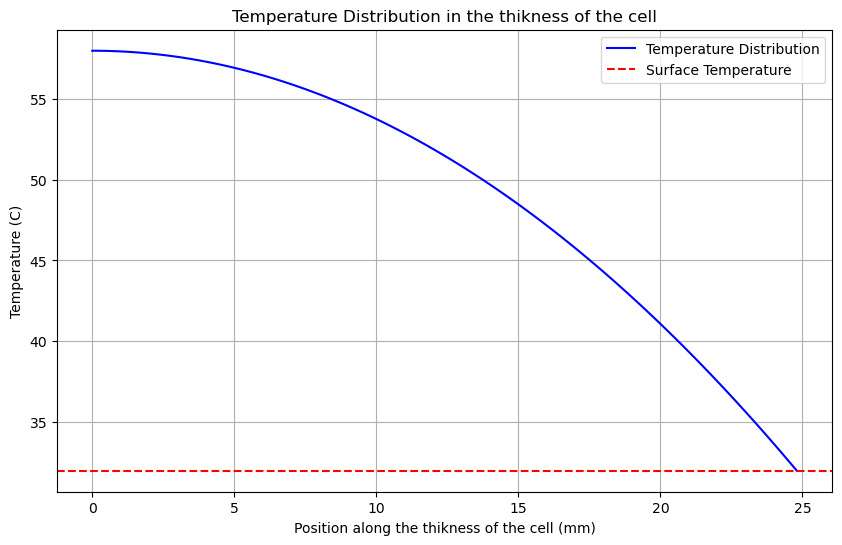

In [3]:
# Define the parameters
k_value = 1  # thermal conductivity [W/m·K]
length = 0.270  # cell length in x [m]
height = 0.106  # cell height in z [m]
thickness = 0.0248  # cell thickness in y [m]
Qtot = 60 # total heat generation [W]
htc = 300.0  # convective heat transfer coefficient [W/m^2·K]
T_env_value = 25  # ambient temperature [C]

A_value = length * height  # cross-sectional area [m^2]
V_value = length * height * thickness  # volume of the rod [m^3]
L_value = thickness  # length of the rod [m]

Rth_value = 1/(A_value*htc)  # thermal resistance [K/W]
q_dot_value =  Qtot/V_value # heat generation rate [W/m^3]
# Substitute the parameters into the final solution
Tsol_final_numeric = Tsol_final.subs({k: k_value, q_dot: q_dot_value, L: L_value,A: A_value, T_env: T_env_value, Rth: Rth_value})
# Display the final solution

display(Tsol_final_numeric)
T_surface = T_env_value + q_dot_value*A_value*L_value * Rth_value

# Define the spatial domain
x_values = np.linspace(0, L_value, 100)  # 100 points from 0 to L

# Calculate the temperature distribution
T_values = [Tsol_final_numeric.subs(x, x_val) for x_val in x_values]

# Plot the temperature distribution
plt.figure(figsize=(10, 6))
plt.plot(x_values*1000, T_values, label='Temperature Distribution', color='blue')
plt.axhline(y=T_surface, color='red', linestyle='--', label='Surface Temperature')
plt.title('Temperature Distribution in the thikness of the cell')
plt.xlabel('Position along the thikness of the cell (mm)')
plt.ylabel('Temperature (C)')
plt.grid()
plt.legend()


